# Trying different perplexity (probability) classification methods

In case we want to build different model than class2.

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys

from pathlib import Path



# Own functions
# Necessary to import from src dir
sys.path.append("../..")
import src.preprocessing_minimal as ppm

## Reading in the data

In [24]:


data_dir = Path('../data')
output_dir = Path('../outputs')

train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
#final_test_df = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date"])

In [25]:
X_train, y_train2, y_train4 = ppm.split_xy(train_df)

## Scaling the data

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

## Correlation exploration

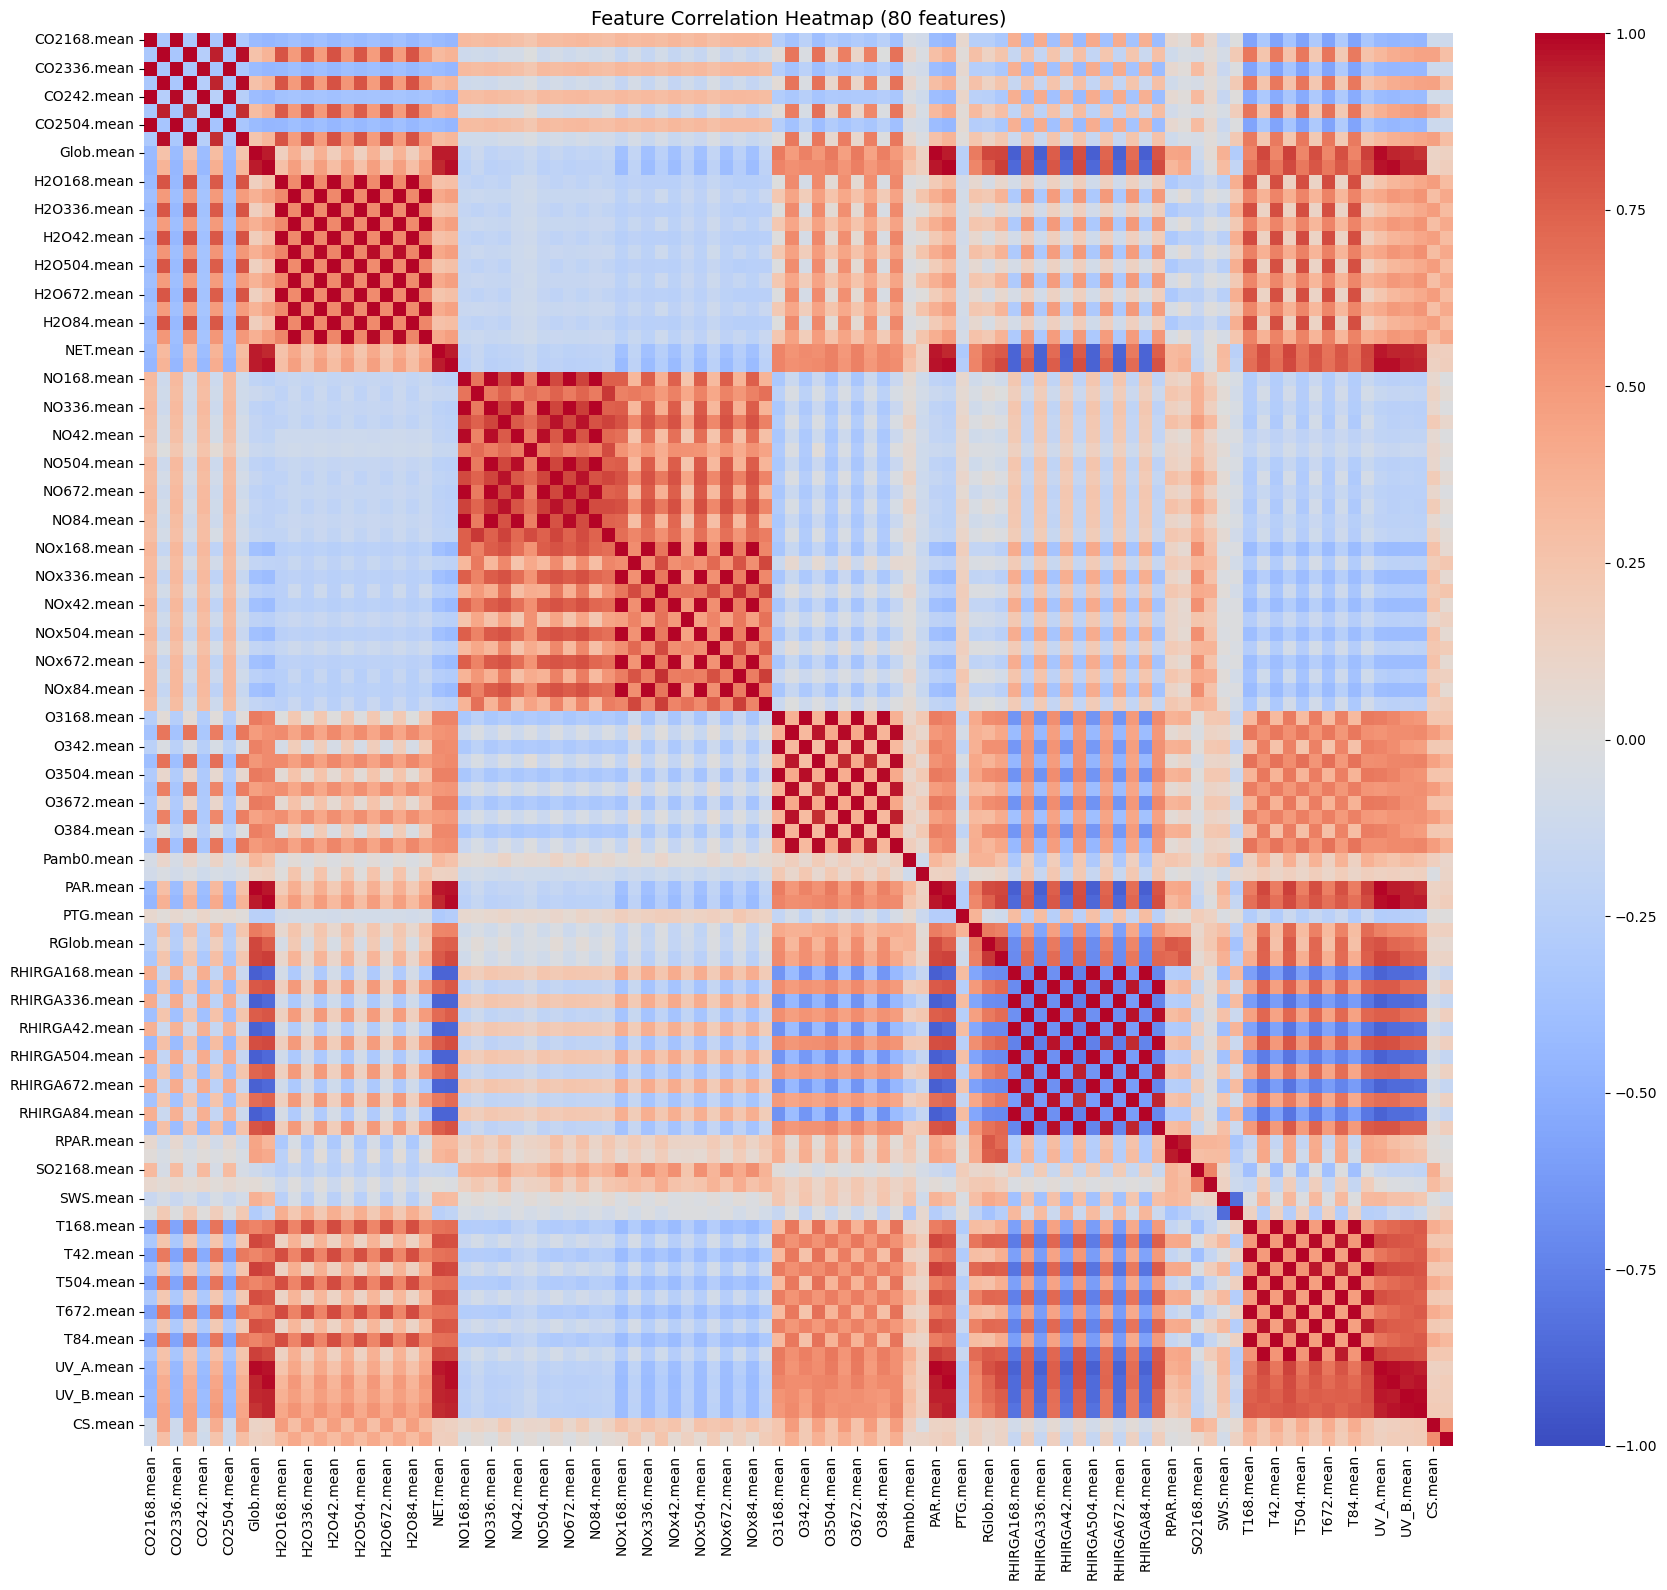

In [27]:
corr = X_train_scaled.corr()

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    corr,
    annot=False,          # too many features for annotations
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap (80 features)', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
threshold = 0.98

# Extract upper triangle only (avoid duplicate pairs)
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Correlation'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > threshold]
high_corr_pairs = high_corr_pairs.sort_values('Correlation', key=abs, ascending=False)

print(f"\n{len(high_corr_pairs)} pairs with |r| > {threshold}:\n")
print(high_corr_pairs.to_string(index=False))

# Candidate features to drop (keep one from each pair)
to_drop = set()
for _, row in high_corr_pairs.iterrows():
    # Drop the second feature in each pair (arbitrary — use domain knowledge)
    to_drop.add(row['Feature_2'])

print(f"\nCandidate features to remove ({len(to_drop)}):", sorted(to_drop))


128 pairs with |r| > 0.98:

     Feature_1      Feature_2  Correlation
      T42.mean       T84.mean     0.999945
   H2O336.mean    H2O504.mean     0.999937
    H2O42.mean     H2O84.mean     0.999923
     T168.mean       T84.mean     0.999921
   H2O504.mean    H2O672.mean     0.999901
   H2O168.mean    H2O336.mean     0.999883
   H2O168.mean     H2O84.mean     0.999819
     T168.mean       T42.mean     0.999808
     T504.mean      T672.mean     0.999802
   H2O336.mean    H2O672.mean     0.999789
   H2O168.mean    H2O504.mean     0.999704
   NOx168.mean     NOx84.mean     0.999691
   CO2168.mean    CO2336.mean     0.999675
     T168.mean      T504.mean     0.999657
   H2O168.mean     H2O42.mean     0.999604
 RHIRGA42.mean  RHIRGA84.mean     0.999542
   CO2336.mean    CO2504.mean     0.999533
   H2O168.mean    H2O672.mean     0.999495
   H2O336.mean     H2O84.mean     0.999468
RHIRGA336.mean RHIRGA504.mean     0.999451
     T504.mean       T84.mean     0.999422
    NO336.mean     NO504.

In [30]:
# Drop the identified features
X_train_scaled = X_train_scaled.drop(columns=to_drop)

KeyError: "['RHIRGA672.mean', 'T672.std', 'PAR.std', 'NO504.mean', 'NO84.mean', 'O384.mean', 'H2O42.std', 'T42.mean', 'CO2336.std', 'NO336.mean', 'CO2504.std', 'RHIRGA42.mean', 'T42.std', 'NOx336.mean', 'CO2504.mean', 'RHIRGA504.mean', 'H2O672.mean', 'O3504.mean', 'T84.std', 'H2O336.mean', 'H2O504.std', 'NOx42.mean', 'UV_B.std', 'H2O336.std', 'H2O42.mean', 'H2O672.std', 'NO42.mean', 'H2O84.std', 'O384.std', 'NOx672.mean', 'T672.mean', 'NO672.mean', 'RHIRGA84.std', 'PAR.mean', 'UV_A.mean', 'RHIRGA672.std', 'RHIRGA504.std', 'O3504.std', 'CO2336.mean', 'RHIRGA84.mean', 'NOx504.mean', 'RHIRGA336.std', 'H2O84.mean', 'O3672.std', 'T84.mean', 'CO242.mean', 'O342.mean', 'O3672.mean', 'NOx84.mean', 'T504.std', 'H2O504.mean', 'UV_A.std', 'T504.mean', 'NET.std', 'RHIRGA336.mean', 'RHIRGA42.std'] not found in axis"